In [1]:
# ==========================================================
# Project: Hospital Readmission Prediction for Diabetes Patients
# Author: Rusul Hayder Abd Zaid
# Part 1: Data Loading and Initial Cleaning
# ==========================================================

import pandas as pd
import numpy as np

# Load the dataset
file_path = 'diabetic_data.csv'

try:
    df = pd.read_csv(file_path)
    print("✅ Successfully loaded the dataset.")
    print(f"Total initial records: {df.shape[0]}")
    print("-" * 50)

    # Identify missing values coded as '?'
    missing_values = (df == '?').sum()
    print("Columns with missing values ('?'):")
    print(missing_values[missing_values > 0])
    print("-" * 50)

    # Handle 'Weight' attribute due to high missingness
    missing_weight_pct = (df['weight'] == '?').mean() * 100
    print(f"Missing Weight Percentage: {missing_weight_pct:.2f}%")

    # Data Cleaning: Dropping redundant or sparse features
    # 'encounter_id' and 'patient_nbr' are identifiers and do not contribute to prediction
    cols_to_drop = ['weight', 'encounter_id', 'patient_nbr', 'payer_code']
    df_cleaned = df.drop(columns=cols_to_drop)

    # Standardizing missing values
    df_cleaned = df_cleaned.replace('?', 'Unknown')

    print("✅ Initial cleaning completed successfully.")
    print(f"Remaining columns: {df_cleaned.shape[1]}")
    print("-" * 50)

    # Preview of cleaned dataset
    print("Preview of cleaned dataset:")
    print(df_cleaned.head())

except FileNotFoundError:
    print("❌ Error: The file 'diabetic_data.csv' was not found. Please re-upload it.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

✅ Successfully loaded the dataset.
Total initial records: 101766
--------------------------------------------------
Columns with missing values ('?'):
race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
dtype: int64
--------------------------------------------------
Missing Weight Percentage: 96.86%
✅ Initial cleaning completed successfully.
Remaining columns: 46
--------------------------------------------------
Preview of cleaned dataset:
              race  gender      age  admission_type_id  \
0        Caucasian  Female   [0-10)                  6   
1        Caucasian  Female  [10-20)                  1   
2  AfricanAmerican  Female  [20-30)                  1   
3        Caucasian    Male  [30-40)                  1   
4        Caucasian    Male  [40-50)                  1   

   discharge_disposition_id  admission_source_id  time_in_hospital  \

/tmp/ipykernel_14047/2603981257.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='readmitted', data=df_cleaned, palette='viridis')


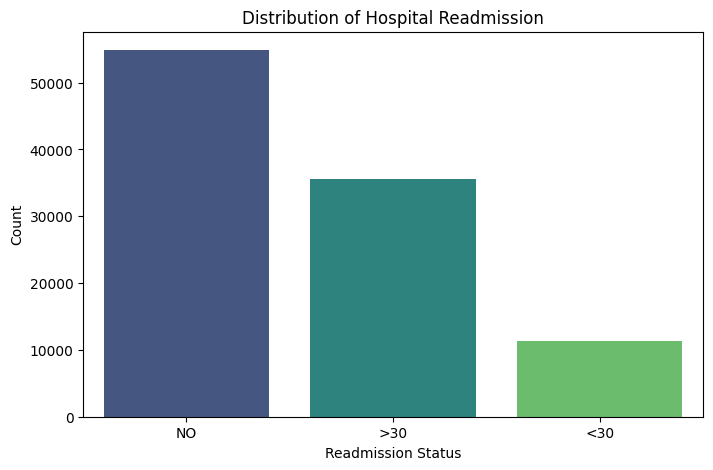

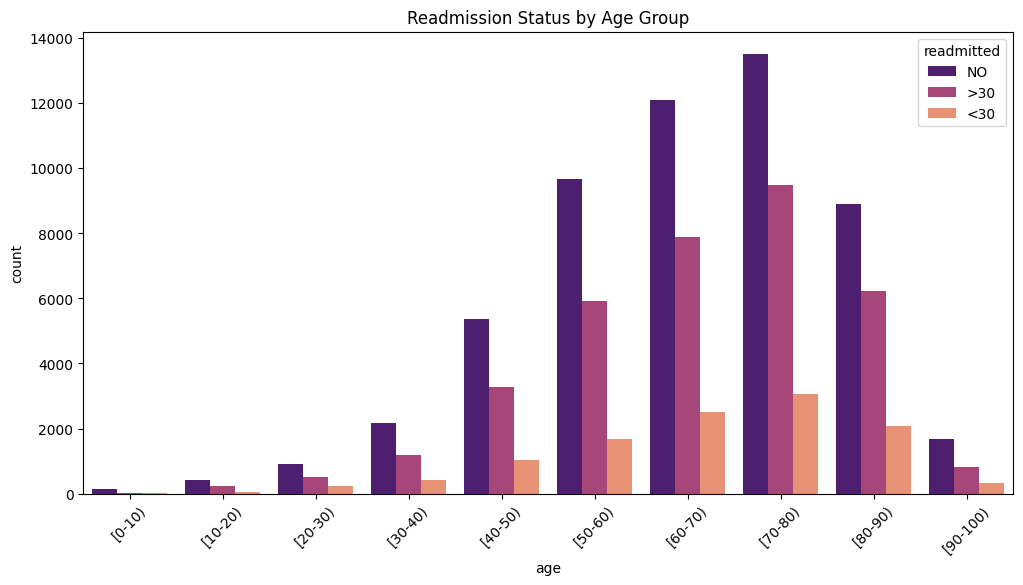

Gender Distribution:
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualization of the Target Variable (Readmission)
plt.figure(figsize=(8,5))
sns.countplot(x='readmitted', data=df_cleaned, palette='viridis')
plt.title('Distribution of Hospital Readmission')
plt.xlabel('Readmission Status')
plt.ylabel('Count')
plt.show()

# 2. Analyzing Readmission by Age Group
plt.figure(figsize=(12,6))
sns.countplot(x='age', hue='readmitted', data=df_cleaned, palette='magma')
plt.title('Readmission Status by Age Group')
plt.xticks(rotation=45)
plt.show()

# 3. Checking for Gender distribution
print("Gender Distribution:")
print(df_cleaned['gender'].value_counts())

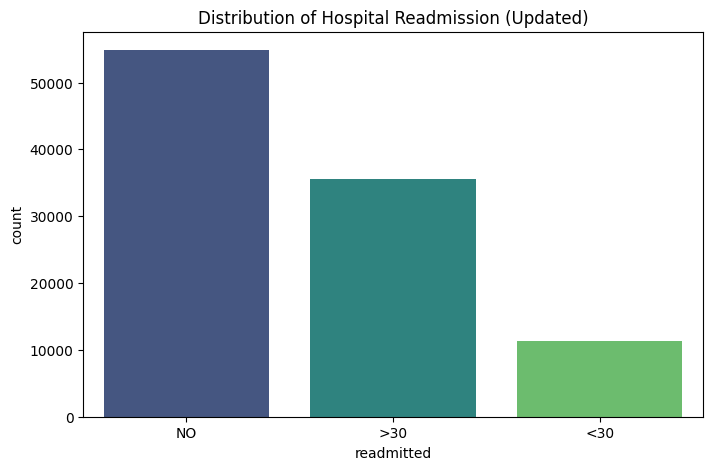

Dataset size after final cleaning: (101763, 46)

Gender counts after removing Unknowns:
gender
Female    54708
Male      47055
Name: count, dtype: int64


In [3]:
# 1. Cleaning the 3 Unknown/Invalid gender rows
df_cleaned = df_cleaned[df_cleaned['gender'] != 'Unknown/Invalid']

# 2. Updated Plot (to remove the Future Warning)
plt.figure(figsize=(8,5))
sns.countplot(x='readmitted', hue='readmitted', data=df_cleaned, palette='viridis', legend=False)
plt.title('Distribution of Hospital Readmission (Updated)')
plt.show()

# 3. Final Check of the Data Shape
print(f"Dataset size after final cleaning: {df_cleaned.shape}")
print("\nGender counts after removing Unknowns:")
print(df_cleaned['gender'].value_counts())

In [4]:
# 1. Map the Target Variable (readmitted) to numbers
# NO -> 0, >30 -> 1, <30 -> 2
readmission_mapping = {'NO': 0, '>30': 1, '<30': 2}
df_cleaned['readmitted_numeric'] = df_cleaned['readmitted'].replace(readmission_mapping)

# 2. Convert Gender to binary (0 and 1)
df_cleaned['gender_numeric'] = df_cleaned['gender'].replace({'Female': 0, 'Male': 1})

# 3. Check the transformation
print("Mapping Summary:")
print(df_cleaned[['readmitted', 'readmitted_numeric', 'gender', 'gender_numeric']].head())

# 4. Success message
print(f"\nNew columns added for modelling: {df_cleaned.columns[-2:].tolist()}")

Mapping Summary:
  readmitted  readmitted_numeric  gender  gender_numeric
0         NO                   0  Female               0
1        >30                   1  Female               0
2         NO                   0  Female               0
3         NO                   0    Male               1
4         NO                   0    Male               1

New columns added for modelling: ['readmitted_numeric', 'gender_numeric']


/tmp/ipykernel_14047/3844372991.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned['readmitted_numeric'] = df_cleaned['readmitted'].replace(readmission_mapping)
/tmp/ipykernel_14047/3844372991.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned['gender_numeric'] = df_cleaned['gender'].replace({'Female': 0, 'Male': 1})


In [5]:
# 1. Identify Categorical Columns (excluding IDs and already mapped columns)
categorical_cols = ['race', 'age', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed']

# 2. Perform One-Hot Encoding
df_final = pd.get_dummies(df_cleaned, columns=categorical_cols, drop_first=True)

# 3. Final Look at the Data
print(f"Original columns: {len(df_cleaned.columns)}")
print(f"New columns after Encoding: {len(df_final.columns)}")
print("\nFirst 5 rows of encoded data:")
print(df_final.head())

Original columns: 48
New columns after Encoding: 62

First 5 rows of encoded data:
   gender  admission_type_id  discharge_disposition_id  admission_source_id  \
0  Female                  6                        25                    1   
1  Female                  1                         1                    7   
2  Female                  1                         1                    7   
3    Male                  1                         1                    7   
4    Male                  1                         1                    7   

   time_in_hospital         medical_specialty  num_lab_procedures  \
0                 1  Pediatrics-Endocrinology                  41   
1                 3                   Unknown                  59   
2                 2                   Unknown                  11   
3                 2                   Unknown                  44   
4                 1                   Unknown                  51   

   num_procedures  num_medi

In [6]:
from sklearn.model_selection import train_test_split

# 1. Define Features (X) and Target (y)
# We use the numeric version of readmitted as our target
X = df_final.drop(['readmitted', 'readmitted_numeric', 'gender', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3'], axis=1)
y = df_final['readmitted_numeric']

# 2. Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Check the sizes
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")
print("\nTarget distribution in Training set (to confirm imbalance):")
print(y_train.value_counts(normalize=True))

Training set size: 81410 rows
Testing set size: 20353 rows

Target distribution in Training set (to confirm imbalance):
readmitted_numeric
0    0.539111
1    0.349294
2    0.111596
Name: proportion, dtype: float64


In [7]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. First, we need to handle some remaining non-numeric columns to avoid errors with SMOTE
# Let's keep only numeric and boolean columns for now
X_train_numeric = X_train.select_dtypes(include=['number', 'bool'])

# 2. Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_numeric, y_train)

# 3. Check the new distribution
print(f"Original training size: {Counter(y_train)}")
print(f"Balanced training size: {Counter(y_train_balanced)}")

# 4. Success message
print("\nSuccess! All classes now have the same number of samples in the training set.")

Original training size: Counter({0: 43889, 1: 28436, 2: 9085})
Balanced training size: Counter({0: 43889, 2: 43889, 1: 43889})

Success! All classes now have the same number of samples in the training set.
